In [1]:
from google.colab import files
uploaded = files.upload()

Saving ethereum.csv to ethereum.csv


In [2]:
import pandas as pd

df = pd.read_csv("ethereum.csv")
df.head()

,Blockno,UnixTimestamp,DateTime (UTC),Value_IN(ETH),Value_OUT(ETH),CurrentValue @ $3083.38454496098/Eth,TxnFee(ETH),TxnFee(USD),Historical $Price/Eth
0,19557289,1711929611,2024-04-01 00:00:11,0.0,0,0.0,0.002915,8.988436,3505.52
1,19557290,1711929623,2024-04-01 00:00:23,0.0,0,0.0,0.004286,13.216714,3505.52
2,19557290,1711929623,2024-04-01 00:00:23,0.0,0,0.0,0.000817,2.520163,3505.52
3,19557291,1711929635,2024-04-01 00:00:35,0.0,0,0.0,0.002683,8.271781,3505.52
4,19557291,1711929635,2024-04-01 00:00:35,0.0,0,0.0,0.003421,10.549526,3505.52


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (5000, 9)

Columns:
 Index(['Blockno', 'UnixTimestamp', 'DateTime (UTC)', 'Value_IN(ETH)',
       'Value_OUT(ETH)', 'CurrentValue @ $3083.38454496098/Eth', 'TxnFee(ETH)',
       'TxnFee(USD)', 'Historical $Price/Eth'],
      dtype='object')

Missing Values:
 Blockno                                 0
UnixTimestamp                           0
DateTime (UTC)                          0
Value_IN(ETH)                           0
Value_OUT(ETH)                          0
CurrentValue @ $3083.38454496098/Eth    0
TxnFee(ETH)                             0
TxnFee(USD)                             0
Historical $Price/Eth                   0
dtype: int64


In [4]:
import numpy as np

df_numeric = df.select_dtypes(include=[np.number])

df_numeric = df_numeric.dropna()

df_numeric.head()

,Blockno,UnixTimestamp,Value_IN(ETH),Value_OUT(ETH),CurrentValue @ $3083.38454496098/Eth,TxnFee(ETH),TxnFee(USD),Historical $Price/Eth
0,19557289,1711929611,0.0,0,0.0,0.002915,8.988436,3505.52
1,19557290,1711929623,0.0,0,0.0,0.004286,13.216714,3505.52
2,19557290,1711929623,0.0,0,0.0,0.000817,2.520163,3505.52
3,19557291,1711929635,0.0,0,0.0,0.002683,8.271781,3505.52
4,19557291,1711929635,0.0,0,0.0,0.003421,10.549526,3505.52


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

model.fit(scaled_data)

df_numeric["anomaly"] = model.predict(scaled_data)
anomaly_count = df_numeric["anomaly"].value_counts()
print(anomaly_count)

anomaly
 1    4900
-1     100
Name: count, dtype: int64


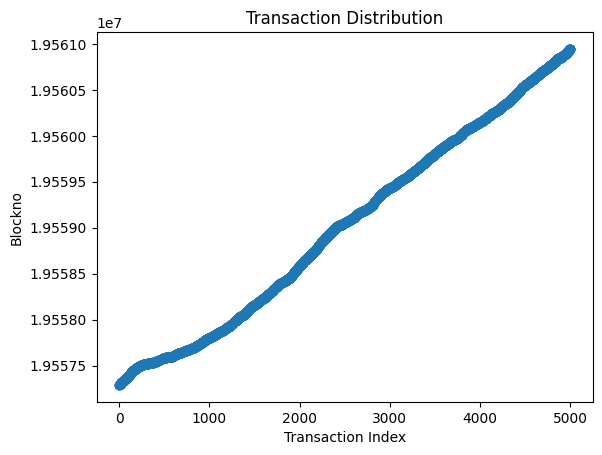

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_numeric.index, df_numeric.iloc[:, 0])
plt.title("Transaction Distribution")
plt.xlabel("Transaction Index")
plt.ylabel(df_numeric.columns[0])
plt.show()

In [9]:
anomalies = df_numeric[df_numeric["anomaly"] == -1]
print("Number of Suspicious Transactions:", len(anomalies))
anomalies.head()

Number of Suspicious Transactions: 100


,Blockno,UnixTimestamp,Value_IN(ETH),Value_OUT(ETH),CurrentValue @ $3083.38454496098/Eth,TxnFee(ETH),TxnFee(USD),Historical $Price/Eth,anomaly
16,19557302,1711929767,1.00,0,3083.384545,0.052035,160.444002,3505.52,-1
29,19557320,1711929983,3.00,0,9250.153635,0.000834,2.572152,3505.52,-1
80,19557365,1711930523,3.50,0,10791.845907,0.004719,14.549752,3505.52,-1
209,19557484,1711931963,4.78,0,14738.578125,0.000881,2.717161,3505.52,-1
256,19557510,1711932275,20.00,0,61667.690899,0.054119,166.869565,3505.52,-1


## Anomaly Detection Using Isolation Forest

Isolation Forest was applied to detect abnormal Ethereum transactions.
Transactions classified as -1 are considered anomalous and may represent:

- Abnormal transaction values
- Suspicious gas usage
- Irregular transaction behavior
- Potential fraudulent wallet activity

This supports scalable anomaly detection in decentralized financial ecosystems.
